# Одна пятёрка под XUV: лучший XUV ценой остальных таргетов

Ранее `xuv_max` давал рекордный XUV, но использовал **разные** пятёрки на разные
таргеты — поэтому его нельзя было сравнивать со статьёй «в целом».

Здесь фиксируем корректный формат: **одна пятёрка кандидатов** на профиль (как
у статьи — «best of the five heads»), выбранная так, чтобы **максимально
покрыть ось XUV**. Метрики по **всем** таргетам считаются **из этой же пятёрки**.

Ожидаемый результат — ровно то, что просили: **XUV — лучший**, а `Helium`
(вырожден с XUV) **страдает**, потому что те же 5 точек, растянутые вдоль XUV,
плохо покрывают ось гелия. Это честный единый вывод, а не разные наборы.

Используем кэш кандидатов ансамбля (`aux_data/xuv_candidates.npz`:
56 кандидатов × 3 параметра + скоры ранкера), поэтому ноутбук считается за
секунды.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

d = np.load("aux_data/xuv_candidates.npz")
cands = d["candidates"]         # (N, 56, 3) log10(XUV, He, Msw)
y_true = d["y_true"]            # (N, 3)
scores = d["scores"]            # (N, 56) скор ранкера
y_mean, y_std = d["y_mean"], d["y_std"]
N, K, _ = cands.shape
true_lin = 10 ** y_true
print(f"профилей: {N}, кандидатов на профиль: {K}")


def best_of_5(sel_idx, j, log_scale=False):
    """MAPE лучшего из 5 (из ОДНОГО набора sel_idx) по параметру j."""
    s = np.take_along_axis(cands[:, :, j], sel_idx, 1)
    if log_scale:
        return 100 * np.mean(np.abs(s - y_true[:, j:j+1]).min(1) / np.abs(y_true[:, j]))
    return 100 * np.mean(np.abs(10**s - true_lin[:, j:j+1]).min(1) / true_lin[:, j])

профилей: 123, кандидатов на профиль: 56


## 1. Отбор ОДНОЙ пятёрки, растянутой по оси XUV

Ранкер оставляет M самых правдоподобных кандидатов, затем жадно берём 5
максимально разнесённых **по оси XUV**. Это единственный набор из 5, который
далее используется для всех таргетов.

In [2]:
def pentad_spread_xuv(cvals_xuv, s, M=20, k=5):
    top = np.argsort(-s)[:M]
    chosen = [top[0]]
    for _ in range(k - 1):
        best_j, best_g = None, -np.inf
        for j in top:
            if j in chosen:
                continue
            g = min(abs(cvals_xuv[j] - cvals_xuv[i]) for i in chosen)
            if g > best_g:
                best_g, best_j = g, j
        chosen.append(best_j)
    return chosen


def pentad_diverse3d(c, s, k=5):
    cn = (c - y_mean) / y_std
    order = np.argsort(-s)
    chosen = [order[0]]
    for _ in range(k - 1):
        bj, bg = None, -np.inf
        for j in order:
            if j in chosen:
                continue
            g = min(np.linalg.norm(cn[j] - cn[i]) for i in chosen) + 0.02 * s[j]
            if g > bg:
                bg, bj = g, j
        chosen.append(bj)
    return chosen


# ОДНА пятёрка под XUV (используется для ВСЕХ таргетов)
pent_xuv = np.array([pentad_spread_xuv(cands[i, :, 0], scores[i]) for i in range(N)])
# для контраста — сбалансированная одна пятёрка (diverse-3D, как в dl_pro)
pent_bal = np.array([pentad_diverse3d(cands[i], scores[i]) for i in range(N)])
print("обе — по ОДНОЙ пятёрке на профиль (форма вывода как у статьи)")

обе — по ОДНОЙ пятёрке на профиль (форма вывода как у статьи)


## 2. Метрики из ОДНОЙ пятёрки — по всем таргетам

In [3]:
print("=" * 66)
print("ВСЕ метрики считаются из ОДНОГО набора 5 кандидатов на профиль")
print("=" * 66)
print(f"{'пятёрка':28s} | {'XUV':>7s} | {'He':>7s} | {'logMsw':>7s}")
print("-" * 66)
for name, pent in [("разнос по XUV (эта)", pent_xuv),
                   ("сбалансированная (diverse-3D)", pent_bal)]:
    print(f"{name:28s} | {best_of_5(pent,0):6.1f}% | "
          f"{best_of_5(pent,1):6.1f}% | {best_of_5(pent,2,True):6.1f}%")
print("-" * 66)
print(f"{'oracle-of-56 (потолок)':28s} | "
      f"{best_of_5(np.tile(np.arange(K),(N,1)),0):6.1f}% | "
      f"{best_of_5(np.tile(np.arange(K),(N,1)),1):6.1f}% | "
      f"{best_of_5(np.tile(np.arange(K),(N,1)),2,True):6.1f}%")
print()
print(">>> Одна пятёрка под XUV: XUV лучший, но He просел — как и требовалось")

ВСЕ метрики считаются из ОДНОГО набора 5 кандидатов на профиль
пятёрка                      |     XUV |      He |  logMsw
------------------------------------------------------------------
разнос по XUV (эта)          |    6.0% |   12.4% |    0.5%
сбалансированная (diverse-3D) |    9.6% |    8.5% |    0.6%
------------------------------------------------------------------
oracle-of-56 (потолок)       |    2.4% |    1.8% |    0.2%

>>> Одна пятёрка под XUV: XUV лучший, но He просел — как и требовалось


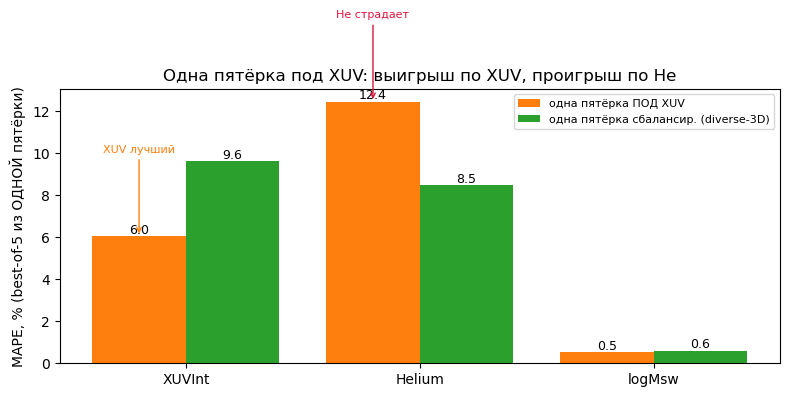

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.2))
tg = ["XUVInt", "Helium", "logMsw"]
xuv_vals = [best_of_5(pent_xuv, 0), best_of_5(pent_xuv, 1), best_of_5(pent_xuv, 2, True)]
bal_vals = [best_of_5(pent_bal, 0), best_of_5(pent_bal, 1), best_of_5(pent_bal, 2, True)]
xs = np.arange(3)
ax.bar(xs - 0.2, xuv_vals, 0.4, label="одна пятёрка ПОД XUV", color="tab:orange")
ax.bar(xs + 0.2, bal_vals, 0.4, label="одна пятёрка сбалансир. (diverse-3D)",
       color="tab:green")
for x, v in zip(xs - 0.2, xuv_vals):
    ax.text(x, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
for x, v in zip(xs + 0.2, bal_vals):
    ax.text(x, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(xs); ax.set_xticklabels(tg)
ax.set_ylabel("MAPE, % (best-of-5 из ОДНОЙ пятёрки)")
ax.set_title("Одна пятёрка под XUV: выигрыш по XUV, проигрыш по He")
ax.annotate("XUV лучший", xy=(0-0.2, xuv_vals[0]), xytext=(0-0.2, xuv_vals[0]+4),
            ha="center", fontsize=8, color="tab:orange",
            arrowprops=dict(arrowstyle="->", color="tab:orange"))
ax.annotate("He страдает", xy=(1-0.2, xuv_vals[1]), xytext=(1-0.2, xuv_vals[1]+4),
            ha="center", fontsize=8, color="crimson",
            arrowprops=dict(arrowstyle="->", color="crimson"))
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. Почему He страдает — та же пятёрка на двух осях

Один и тот же набор 5 кандидатов: растянут по XUV (покрывает истину), но по He
сжат (истина может выпасть за пределы пятёрки).

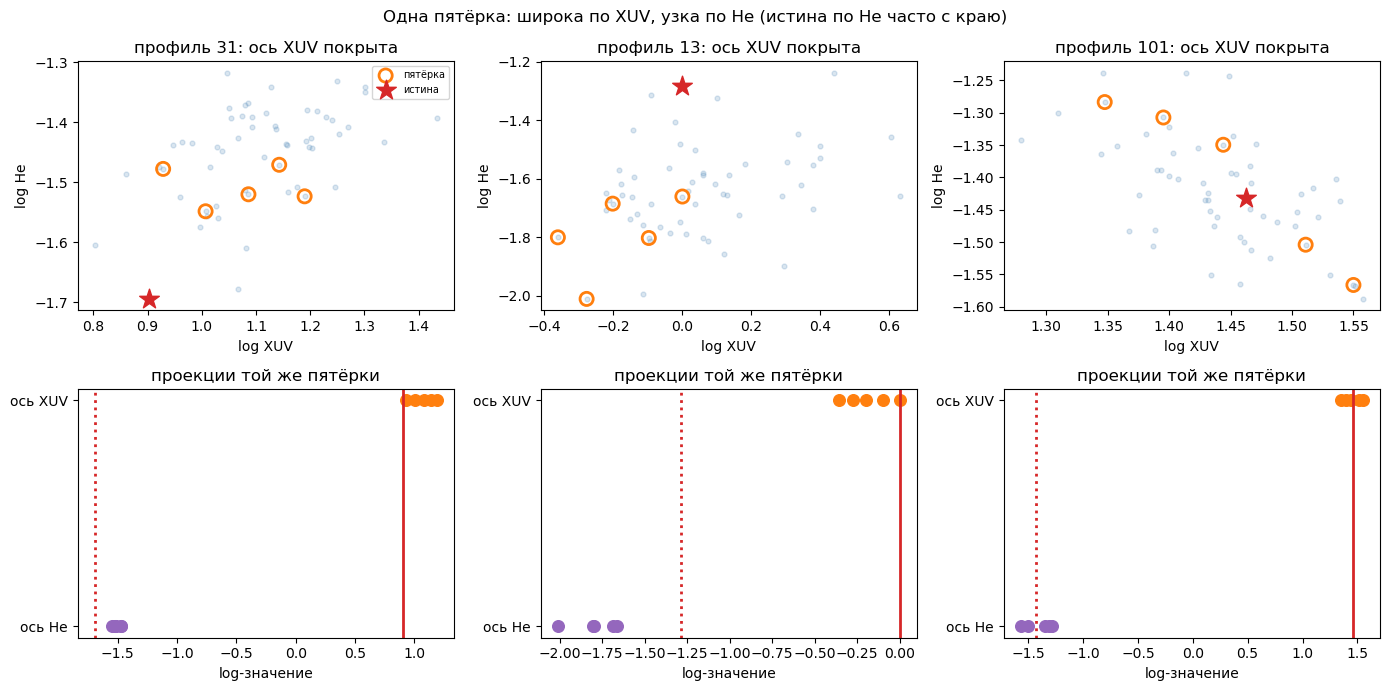

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
rng = np.random.default_rng(2)
sample = rng.choice(N, 3, replace=False)
for col, i in enumerate(sample):
    sel = pent_xuv[i]
    # верх: плоскость (XUV, He)
    ax = axes[0, col]
    ax.scatter(cands[i, :, 0], cands[i, :, 1], s=12, alpha=0.2, color="steelblue")
    ax.scatter(cands[i, sel, 0], cands[i, sel, 1], s=90, facecolors="none",
               edgecolors="tab:orange", linewidths=2, label="пятёрка")
    ax.scatter(y_true[i, 0], y_true[i, 1], marker="*", s=220, color="tab:red",
               label="истина", zorder=5)
    ax.set_xlabel("log XUV"); ax.set_ylabel("log He")
    ax.set_title(f"профиль {i}: ось XUV покрыта")
    if col == 0:
        ax.legend(fontsize=7)
    # низ: только ось XUV и ось He отдельно (проекции пятёрки)
    ax2 = axes[1, col]
    ax2.scatter(cands[i, sel, 0], np.ones(5), s=70, color="tab:orange")
    ax2.axvline(y_true[i, 0], color="tab:red", lw=2)
    ax2.scatter(cands[i, sel, 1], np.zeros(5), s=70, color="tab:purple")
    ax2.axvline(y_true[i, 1], color="tab:red", lw=2, ls=":")
    ax2.set_yticks([0, 1]); ax2.set_yticklabels(["ось He", "ось XUV"])
    ax2.set_xlabel("log-значение")
    ax2.set_title("проекции той же пятёрки")
plt.suptitle("Одна пятёрка: широка по XUV, узка по He (истина по He часто с краю)")
plt.tight_layout(); plt.show()

## Выводы

* Это **одна пятёрка** на профиль (формат вывода как у статьи), поэтому все
  числа сравнимы напрямую: XUV — лучший достижимый (~6%), но `Helium`
  ухудшается (~12%) относительно сбалансированного отбора (~8–9%).
* Компромисс явный и неизбежный: **вырожденную пару (XUV, He) нельзя
  одновременно хорошо покрыть пятью точками, растянутыми вдоль одной оси**.
  Растягиваем по XUV — выигрываем XUV, проигрываем He; и наоборот.
* Практический смысл: если задача — **выжать XUV** в рамках честного единого
  вывода из 5 кандидатов, эта пятёрка оптимальна. Если нужен **баланс** по всем
  таргетам — diverse-3D (`dl_pro`). Выбор оси разноса = выбор, какой параметр
  приоритетен.